In [17]:
!pip install numpy
!pip install torch torchvision torchaudio  
!pip install scikit-learn
!pip install tqdm
!pip install matplotlib
!pip install seaborn
!pip install opencv-python

In [ ]:
import os
import random
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, TensorDataset
import torchvision
from torchvision import transforms
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
import cv2

# Config values
USE_DUMMY_DATA = False    
IMAGE_FOLDER_PATH = "./data"
BATCH_SIZE = 32
EPOCHS = 15
EXTRA_TREES_N = 50
EXTRA_TREES_CRITERION = 'gini'
TOP_K_FEATURES = 4323
LR = 1e-3
RANDOM_SEED = 42

# Set seeds
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cpu


In [19]:
# === Dataset helpers ===
from torchvision import datasets
from torch.utils.data import random_split

imagenet_mean = [0.485, 0.456, 0.406]
imagenet_std  = [0.229, 0.224, 0.225]

def build_imagefolder_datasets(root_folder, batch_size=32, train_ratio=0.8):
    """
    Loads dataset from folder structure and splits into train/test.
    root_folder/
        Benign cases/
        Malignant cases/
        Normal cases/
    """
    transform = transforms.Compose([
        transforms.Resize((224,224)),
        transforms.ToTensor(),
        transforms.Normalize(mean=imagenet_mean, std=imagenet_std)
    ])

    dataset = datasets.ImageFolder(root=root_folder, transform=transform)

    # Train/test split sizes
    train_size = int(train_ratio * len(dataset))
    test_size = len(dataset) - train_size

    train_dataset, test_dataset = random_split(dataset, [train_size, test_size])

    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=2)
    test_loader  = DataLoader(test_dataset,  batch_size=batch_size, shuffle=False, num_workers=2)

    return train_loader, test_loader, dataset.classes

In [20]:
# === VGG16 feature extractor ===
def build_vgg16_extractor(device):
    vgg = torchvision.models.vgg16(weights=torchvision.models.VGG16_Weights.IMAGENET1K_V1)
    for param in vgg.parameters():
        param.requires_grad = False
    vgg.to(device)
    vgg.eval()
    return vgg

def extract_features_from_numpy_images(vgg_model, X_numpy, batch_size=32, device='cpu'):
    feats_list = []
    n = X_numpy.shape[0]
    with torch.no_grad():
        for i in range(0, n, batch_size):
            batch = X_numpy[i:i+batch_size]
            batch_t = torch.from_numpy(batch).to(device)
            mean = torch.tensor(imagenet_mean, dtype=torch.float32, device=device).view(1,3,1,1)
            std  = torch.tensor(imagenet_std, dtype=torch.float32, device=device).view(1,3,1,1)
            batch_t = (batch_t - mean) / std
            x = vgg_model.features(batch_t)
            x = vgg_model.avgpool(x)
            x = torch.flatten(x, 1)
            feats_list.append(x.cpu().numpy())
    return np.vstack(feats_list)

In [21]:
# === ExtraTrees feature selection ===
def select_top_k_features_extra_trees(X_train, y_train,
                                      n_estimators=EXTRA_TREES_N,
                                      criterion=EXTRA_TREES_CRITERION,
                                      top_k=TOP_K_FEATURES,
                                      random_state=RANDOM_SEED):
    et = ExtraTreesClassifier(n_estimators=n_estimators,
                              criterion=criterion,
                              random_state=random_state,
                              n_jobs=-1)
    print("Fitting ExtraTrees...")
    et.fit(X_train, y_train)
    importances = et.feature_importances_
    top_k = min(top_k, X_train.shape[1])
    top_idx = np.argsort(importances)[-top_k:]
    top_idx_sorted = np.sort(top_idx)
    return et, top_idx_sorted, X_train[:, top_idx_sorted], importances

In [22]:
# === Simple MLP ===
class SimpleMLP(nn.Module):
    def __init__(self, input_dim, hidden1=100, hidden2=70, n_classes=3):
        super().__init__()
        self.fc1 = nn.Linear(input_dim, hidden1)
        self.relu1 = nn.ReLU(inplace=True)
        self.fc2 = nn.Linear(hidden1, hidden2)
        self.relu2 = nn.ReLU(inplace=True)
        self.fc3 = nn.Linear(hidden2, n_classes)
    def forward(self, x):
        x = self.fc1(x)
        x = self.relu1(x)
        x = self.fc2(x)
        x = self.relu2(x)
        x = self.fc3(x)
        return x

In [23]:
# === Training and evaluation helpers ===
def train_mlp(model, train_loader, device, epochs=EPOCHS, lr=LR):
    model.to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    criterion = nn.CrossEntropyLoss()
    
    # For tracking training progress
    train_losses = []
    train_accuracies = []
    
    for epoch in range(1, epochs+1):
        model.train()
        running_loss, correct, total = 0, 0, 0
        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device)
            optimizer.zero_grad()
            outputs = model(xb)
            loss = criterion(outputs, yb)
            loss.backward()
            optimizer.step()
            running_loss += loss.item()*xb.size(0)
            preds = outputs.argmax(dim=1)
            total += yb.size(0)
            correct += (preds == yb).sum().item()
        
        epoch_loss = running_loss/total
        epoch_accuracy = correct/total
        train_losses.append(epoch_loss)
        train_accuracies.append(epoch_accuracy)
        
        print(f"Epoch {epoch}/{epochs}  Loss: {epoch_loss:.4f}  Train Acc: {epoch_accuracy:.2f}")
    
    return model, train_losses, train_accuracies

def evaluate_mlp(model, loader, device):
    model.eval()
    total, correct = 0, 0
    all_preds = []
    all_labels = []
    with torch.no_grad():
        for xb, yb in loader:
            xb, yb = xb.to(device), yb.to(device)
            outputs = model(xb)
            preds = outputs.argmax(dim=1)
            total += yb.size(0)
            correct += (preds == yb).sum().item()
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(yb.cpu().numpy())
    return correct/total, all_preds, all_labels

In [24]:
# === Function to classify a single image ===
def classify_image(image_path, vgg_model, mlp_model, top_k_indices, class_names, device):
    """
    Classify a single image using the trained model
    """
    # Load and preprocess the image using OpenCV
    image_cv = cv2.imread(image_path)
    if image_cv is None:
        raise ValueError(f"Could not load image from path: {image_path}")
    
    image_cv = cv2.cvtColor(image_cv, cv2.COLOR_BGR2RGB)
    image_pil = Image.fromarray(image_cv)
    
    transform = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize(mean=imagenet_mean, std=imagenet_std)
    ])
    image_tensor = transform(image_pil).unsqueeze(0).to(device)
    
    # Extract features using VGG16
    with torch.no_grad():
        vgg_model.eval()
        features = vgg_model.features(image_tensor)
        features = vgg_model.avgpool(features)
        features = torch.flatten(features, 1)
        features = features.cpu().numpy()
    
    # Select top features using ExtraTrees indices
    features_selected = features[:, top_k_indices]
    
    # Convert to tensor and predict
    features_tensor = torch.from_numpy(features_selected).float().to(device)
    with torch.no_grad():
        mlp_model.eval()
        output = mlp_model(features_tensor)
        probabilities = torch.softmax(output, dim=1)
        confidence, predicted_class = torch.max(probabilities, 1)
    
    return class_names[predicted_class.item()], confidence.item(), image_pil

In [25]:
# === Visualization functions ===
def plot_training_history(train_losses, train_accuracies):
    """Plot training loss and accuracy over epochs"""
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
    
    # Plot training loss
    ax1.plot(train_losses, label='Training Loss')
    ax1.set_title('Training Loss')
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Loss')
    ax1.legend()
    ax1.grid(True)
    
    # Plot training accuracy
    ax2.plot(train_accuracies, label='Training Accuracy', color='orange')
    ax2.set_title('Training Accuracy')
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('Accuracy')
    ax2.legend()
    ax2.grid(True)
    
    plt.tight_layout()
    plt.show()

def plot_feature_importances(importances, top_k_indices, top_k=20):
    """Plot the top K feature importances"""
    # Get the top K importances and their indices
    top_indices = top_k_indices[-top_k:]
    top_importances = importances[top_indices]
    
    plt.figure(figsize=(10, 6))
    plt.barh(range(len(top_importances)), top_importances)
    plt.yticks(range(len(top_importances)), [f'Feature {i}' for i in top_indices])
    plt.xlabel('Importance')
    plt.title(f'Top {top_k} Feature Importances')
    plt.tight_layout()
    plt.show()

def plot_confusion_matrix(all_labels, all_preds, class_names):
    """Plot confusion matrix as a heatmap"""
    cm = confusion_matrix(all_labels, all_preds)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=class_names, 
                yticklabels=class_names)
    plt.title('Confusion Matrix')
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.tight_layout()
    plt.show()

def display_image_with_prediction(image, prediction, confidence):
    """Display an image with its prediction"""
    plt.figure(figsize=(6, 6))
    plt.imshow(image)
    plt.title(f'Prediction: {prediction}\\nConfidence: {confidence:.2%}')
    plt.axis('off')
    plt.tight_layout()
    plt.show()

Classes: ['Bengin cases', 'Malignant cases', 'Normal cases']
Extracting VGG16 features for training set...
Extracting VGG16 features for test set...
Train features: (877, 25088)  Test features: (220, 25088)
Dataset Train features extracted: (877, 25088) Dataset Test features extracted: (220, 25088)
Fitting ExtraTrees...
Train features selected: (877, 4323) Test features selected: (220, 4323)
Training SimpleMLP...
Epoch 1/15  Loss: 0.4000  Train Acc: 0.85
Epoch 2/15  Loss: 0.1437  Train Acc: 0.95
Epoch 3/15  Loss: 0.0773  Train Acc: 0.97
Epoch 4/15  Loss: 0.0328  Train Acc: 0.99
Epoch 5/15  Loss: 0.0106  Train Acc: 1.00
Epoch 6/15  Loss: 0.0044  Train Acc: 1.00
Epoch 7/15  Loss: 0.0031  Train Acc: 1.00
Epoch 8/15  Loss: 0.0014  Train Acc: 1.00
Epoch 9/15  Loss: 0.0012  Train Acc: 1.00
Epoch 10/15  Loss: 0.0012  Train Acc: 1.00
Epoch 11/15  Loss: 0.0005  Train Acc: 1.00
Epoch 12/15  Loss: 0.0004  Train Acc: 1.00
Epoch 13/15  Loss: 0.0003  Train Acc: 1.00
Epoch 14/15  Loss: 0.0002  Train 

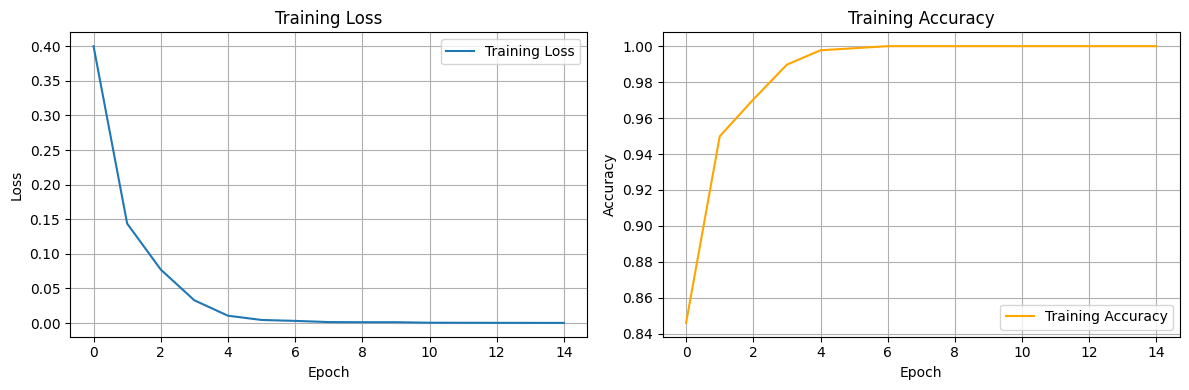

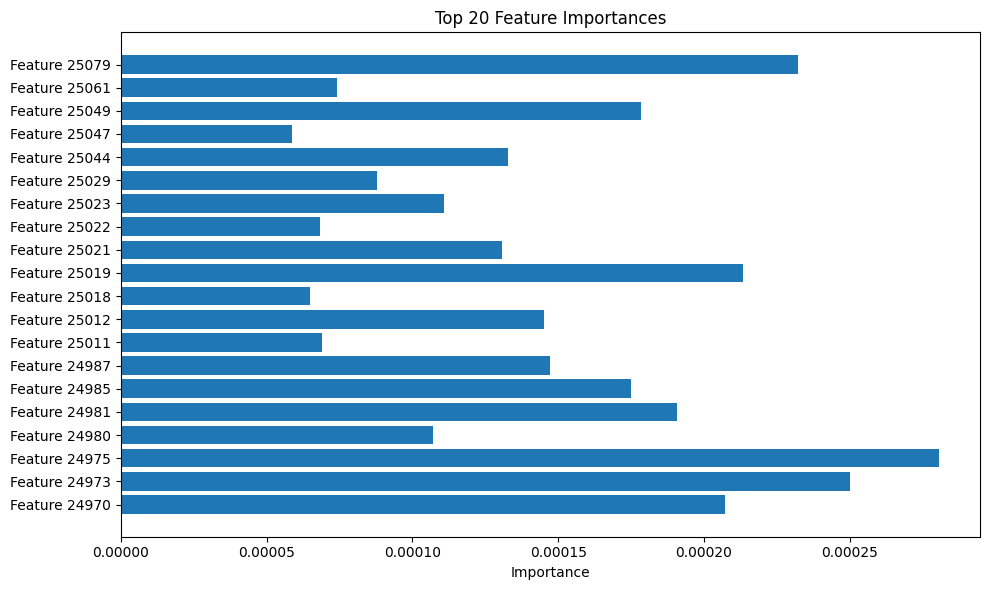

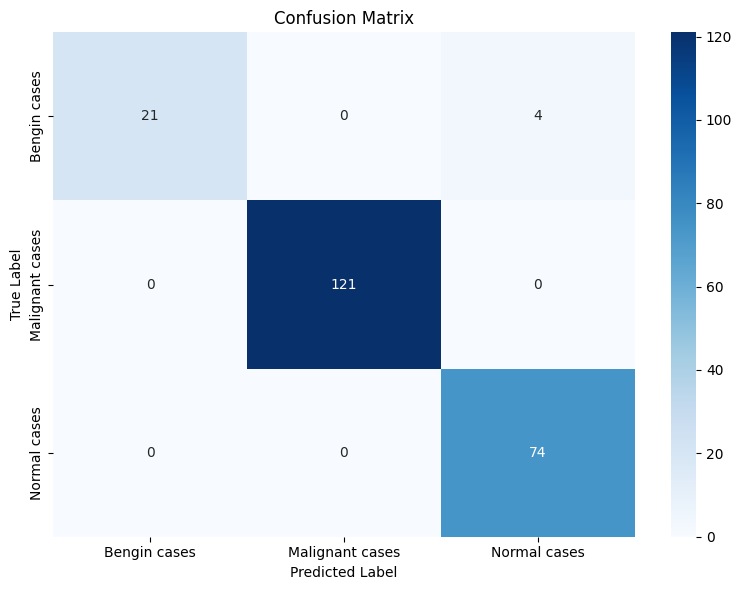


Testing with sample image: D:\\project exhibition\\NEW MODEL\\dataset\\Lung\Bengin cases\Bengin case (1).jpg


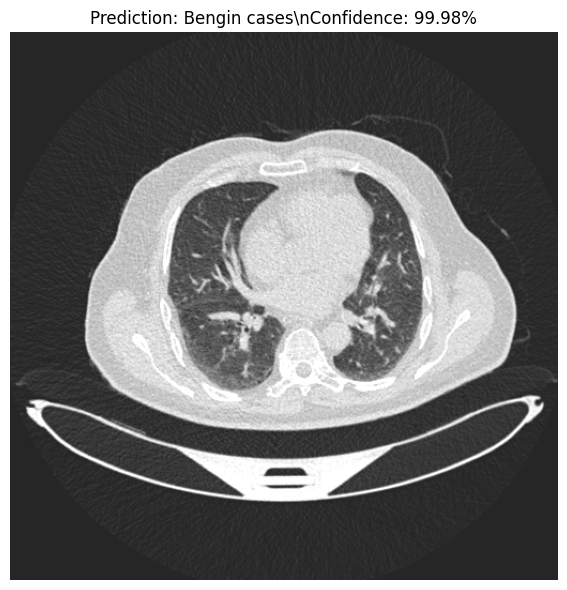

Classification: Bengin cases with 99.98% confidence

Minimum Viable Product (MVP):
The MVP of this image classification model is a system that can take an input image and classify it into one of the predefined categories (e.g., Benign, Malignant, Normal) with a basic level of accuracy. This involves the core components of image loading, feature extraction (using a pre-trained model like VGG16), feature selection, and a simple classifier (like the MLP) to make a prediction. The MVP would demonstrate the feasibility of the overall approach, even if the performance is not yet optimized for real-world deployment.

Discussion on Efficiency Improvements:
1. Data Loading and Preprocessing:
   - Current: Loading images from disk, resizing, and normalizing.
   - Potential Improvement: Implement faster data loading with multiple workers (num_workers in DataLoader), consider data augmentation on the GPU if possible.
2. Feature Extraction:
   - Current: Using VGG16, which is computationally expens

In [28]:
# === Full pipeline ===

# Step 1: Load dataset (train/test split automatically)
dataset_path = r"D:\\project exhibition\\NEW MODEL\\dataset\\Lung"   
train_loader, test_loader, class_names = build_imagefolder_datasets(dataset_path, batch_size=BATCH_SIZE)

print("Classes:", class_names)

# Step 2: Extract VGG16 features for train/test separately
vgg = build_vgg16_extractor(device)

def extract_features_from_loader(vgg_model, loader, device):
    feats_list, labels_list = [], []
    with torch.no_grad():
        for imgs, labels in loader:
            imgs = imgs.to(device)
            feats = vgg_model.features(imgs)
            feats = vgg_model.avgpool(feats)
            feats = torch.flatten(feats, 1)
            feats_list.append(feats.cpu().numpy())
            labels_list.append(labels.numpy())
    return np.vstack(feats_list), np.concatenate(labels_list)

print("Extracting VGG16 features for training set...")
X_train, y_train = extract_features_from_loader(vgg, train_loader, device)

print("Extracting VGG16 features for test set...")
X_test, y_test = extract_features_from_loader(vgg, test_loader, device)

print("Train features:", X_train.shape, " Test features:", X_test.shape)

# Step 3: Feature selection using ExtraTrees
print("Dataset Train features extracted:", X_train.shape, "Dataset Test features extracted:", X_test.shape)
et_model, top_k_indices, X_train_selected, feature_importances = select_top_k_features_extra_trees(X_train, y_train, top_k=TOP_K_FEATURES)
X_test_selected = X_test[:, top_k_indices]

print("Train features selected:", X_train_selected.shape, "Test features selected:", X_test_selected.shape)

# Step 4: Convert data to PyTorch tensors and create DataLoaders
X_train_tensor = torch.from_numpy(X_train_selected).float()
y_train_tensor = torch.from_numpy(y_train).long()
X_test_tensor = torch.from_numpy(X_test_selected).float()
y_test_tensor = torch.from_numpy(y_test).long()

train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

# Step 5: Instantiate and train the SimpleMLP model
input_dim = X_train_selected.shape[1]
n_classes = len(class_names)
model = SimpleMLP(input_dim=input_dim, n_classes=n_classes)

print("Training SimpleMLP...")
model, train_losses, train_accuracies = train_mlp(model, train_loader, device, epochs=EPOCHS, lr=LR)

# Step 6: Evaluate the model
accuracy, all_preds, all_labels = evaluate_mlp(model, test_loader, device)
print(f"Test Accuracy: {accuracy:.4f}")

# Step 7: Visualizations
# 1. Plot training history
plot_training_history(train_losses, train_accuracies)

# 2. Plot feature importances
plot_feature_importances(feature_importances, top_k_indices, top_k=20)

# 3. Plot confusion matrix
plot_confusion_matrix(all_labels, all_preds, class_names)

# Step 8: Test with a sample image
# Find a sample image from the test set to demonstrate classification
sample_image_path = None
for root, dirs, files in os.walk(dataset_path):
    for file in files:
        if file.lower().endswith(('.png', '.jpg', '.jpeg')):
            sample_image_path = os.path.join(root, file)
            break
    if sample_image_path:
        break

if sample_image_path:
    print(f"\nTesting with sample image: {sample_image_path}")
    prediction, confidence, image = classify_image(
        sample_image_path, vgg, model, top_k_indices, class_names, device
    )
    display_image_with_prediction(image, prediction, confidence)
    print(f"Classification: {prediction} with {confidence:.2%} confidence")
else:
    print("No sample image found for testing")

print("\nMinimum Viable Product (MVP):")
print("The MVP of this image classification model is a system that can take an input image and classify it into one of the predefined categories (e.g., Benign, Malignant, Normal) with a basic level of accuracy. This involves the core components of image loading, feature extraction (using a pre-trained model like VGG16), feature selection, and a simple classifier (like the MLP) to make a prediction. The MVP would demonstrate the feasibility of the overall approach, even if the performance is not yet optimized for real-world deployment.")

print("\nDiscussion on Efficiency Improvements:")
print("1. Data Loading and Preprocessing:")
print("   - Current: Loading images from disk, resizing, and normalizing.")
print("   - Potential Improvement: Implement faster data loading with multiple workers (num_workers in DataLoader), consider data augmentation on the GPU if possible.")
print("2. Feature Extraction:")
print("   - Current: Using VGG16, which is computationally expensive.")
print("   - Potential Improvement: Explore more efficient pre-trained models (e.g., MobileNet, EfficientNet) that offer a better trade-off between accuracy and computational cost. Quantization or pruning of the feature extractor could also be considered.")
print("3. Feature Selection:")
print("   - Current: ExtraTrees classifier to select top K features.")
print("   - Potential Improvement: While ExtraTrees is relatively fast, consider if feature selection is strictly necessary or if a different approach like using global average pooling instead of flattening the VGG16 output could reduce the feature dimension more efficiently. Other feature selection methods like L1 regularization during training could also be explored.")
print("4. Model Training:")
print("   - Current: Simple MLP.")
print("   - Potential Improvement: Optimize the MLP architecture (number of layers, neurons). Use techniques like learning rate scheduling, earlier stopping, or mixed precision training to speed up convergence and reduce training time. Training on a GPU is crucial for efficiency.")
print("5. End-to-End Model:")
print("   - Consider fine-tuning the pre-trained VGG16 model or a more efficient CNN architecture directly on the image data instead of using a separate feature extraction and MLP step. This allows the model to learn features more relevant to the specific classification task.")
print("   - Implement the entire pipeline as a single, trainable model for potentially better performance and easier deployment.")

In [ ]:
# Add this to your notebook after training
torch.save(model.state_dict(), mlp_model.pth')
np.save('top_k_indices.npy', top_k_indices)